SHAP

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (10, 4)

In [2]:
SEED = 42

import os
import random

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [3]:
DATA_PATH = "/kaggle/input/datasets/ghgqwer/data-1/train_2.csv"
# DATA_PATH = "train_2.csv"


df = pd.read_csv(DATA_PATH)
print("shape:", df.shape)
print("columns:", list(df.columns))
display(df.head(5))

shape: (485082, 24)
columns: ['new_id', 'Год', 'Месяц', 'Среднее количество промо товаров в чеке', 'Среднее количество товаров в чеке', 'Среднее количество отмен', 'Рабочие часы в день', 'Дата открытия, категориальный', 'Торговая площадь, категориальный', 'Населенный пункт', 'Регион', 'Численность населения', 'Количество домохозяйств', 'Трафик пеший, в час', 'Трафик авто, в час', 'Маркетплейсы, доставки, постаматы (100 м)', 'Медицинские уч. и аптеки (300 м)', 'Школы (300 м)', 'Остановки (300 м)', 'Продуктовые магазины (500 м)', 'Пятерочки (500 м)', 'Количество касс', 'Флаг алкогольной лицензии', 'РТО']


,new_id,Год,Месяц,Среднее количество промо товаров в чеке,Среднее количество товаров в чеке,Среднее количество отмен,Рабочие часы в день,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,Регион,Численность населения,Количество домохозяйств,"Трафик пеший, в час","Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО
0,0,2024,1,1.08,6.03,147.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,75147744.85
1,0,2023,1,1.32,6.04,162.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,74914754.22
2,0,2025,1,0.82,6.00,145.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,87125506.92
3,0,2025,2,0.90,6.00,118.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,82659801.63
4,0,2024,2,1.25,6.06,154.0,16.0,Новый,Большой,Ярославль г,Ярославская обл,603883,3775,138,73,1,0,0,0,3,1,10,1,74209339.11


In [4]:
df.columns = df.columns.str.replace(',', '', regex=False)
df.columns

Index(['new_id', 'Год', 'Месяц', 'Среднее количество промо товаров в чеке', 'Среднее количество товаров в чеке', 'Среднее количество отмен', 'Рабочие часы в день', 'Дата открытия категориальный',
       'Торговая площадь категориальный', 'Населенный пункт', 'Регион', 'Численность населения', 'Количество домохозяйств', 'Трафик пеший в час', 'Трафик авто в час',
       'Маркетплейсы доставки постаматы (100 м)', 'Медицинские уч. и аптеки (300 м)', 'Школы (300 м)', 'Остановки (300 м)', 'Продуктовые магазины (500 м)', 'Пятерочки (500 м)', 'Количество касс',
       'Флаг алкогольной лицензии', 'РТО'],
      dtype='object')

In [5]:
mean_cols = [c for c in df.columns if "Среднее" in str(c)]
mean_cols

['Среднее количество промо товаров в чеке',
 'Среднее количество товаров в чеке',
 'Среднее количество отмен']

# Prepare

In [24]:
import numpy as np
import pandas as pd
import calendar

def create_features_for_month(df, target_year, target_month, inflation_dict=None):
    """
    Функция собирает обучающие или тестовые признаки для конкретного целевого месяца.
    Все признаки, связанные с РТО, рассчитываются в логарифмической шкале (log1p).
    """
    
    static_cols = [
        'new_id', 'Регион', 'Населенный пункт', 'Торговая площадь категориальный',
        'Дата открытия категориальный', 'Количество домохозяйств', 'Количество касс',
        'Трафик пеший в час', 'Трафик авто в час',
        'Маркетплейсы доставки постаматы (100 м)', 'Медицинские уч. и аптеки (300 м)', 
        'Школы (300 м)', 'Остановки (300 м)', 'Продуктовые магазины (500 м)', 'Пятерочки (500 м)'
    ]

    base_df = df[static_cols].drop_duplicates(subset=['new_id']).copy()
    
    target_time_value = target_year * 12 + target_month
    history_before_target = df[(df['Год'] * 12 + df['Месяц']) < target_time_value].copy()
    
    metrics_to_agg = [
        'Среднее количество промо товаров в чеке',
        'Среднее количество товаров в чеке',
        'Среднее количество отмен'
    ]

    shop_profile = history_before_target.groupby('new_id')[metrics_to_agg].mean().reset_index()

    cols_to_keep = ['new_id'] + metrics_to_agg
    base_df = base_df.merge(shop_profile[cols_to_keep], on='new_id', how='left')

    for col in cols_to_keep:
        if col != 'new_id':
            base_df[col] = base_df[col].fillna(0)
    
    base_df['Регион_Город'] = base_df['Регион'].astype(str) + "_" + base_df['Населенный пункт'].astype(str)
    
    def get_historical_rto(shift_months):
        total_months = target_year * 12 + (target_month - 1) - shift_months
        hist_y = total_months // 12
        hist_m = (total_months % 12) + 1
        
        hist_slice = df[(df['Год'] == hist_y) & (df['Месяц'] == hist_m)][['new_id', 'РТО']].copy()
        hist_slice[f'log_rto_lag_{shift_months}'] = np.log1p(hist_slice['РТО'])
        return hist_slice[['new_id', f'log_rto_lag_{shift_months}']]

    base_df = base_df.merge(get_historical_rto(1), on='new_id', how='left')
    base_df = base_df.merge(get_historical_rto(2), on='new_id', how='left')
    base_df = base_df.merge(get_historical_rto(6), on='new_id', how='left')
    base_df = base_df.merge(get_historical_rto(12), on='new_id', how='left')

    base_df['log_rto_yoy_diff'] = base_df['log_rto_lag_1'] - base_df['log_rto_lag_12']
    base_df['reg_rto_yoy_trend'] = base_df.groupby('Регион')['log_rto_yoy_diff'].transform('mean')

    region_lag1_mean = base_df.groupby('Регион')['log_rto_lag_1'].transform('mean') 
    base_df['log_rto_vs_region'] = base_df['log_rto_lag_1'] - region_lag1_mean

    history_before_target['log_РТО'] = np.log1p(history_before_target['РТО'])
    
    def get_rolling_stats(window_months):
        window_df = history_before_target[
            (target_time_value - (history_before_target['Год'] * 12 + history_before_target['Месяц'])) <= window_months
        ]
        agg_df = window_df.groupby('new_id')['log_РТО'].agg(['mean', 'std']).reset_index()
        agg_df.columns = [
            'new_id', 
            f'log_rto_roll_{window_months}m_mean', 
            f'log_rto_roll_{window_months}m_std'
        ]
        return agg_df
    
    base_df = base_df.merge(get_rolling_stats(3), on='new_id', how='left')
    base_df = base_df.merge(get_rolling_stats(6), on='new_id', how='left')
    
    roll_cols = [c for c in base_df.columns if 'log_rto_' in c]
    # for c in roll_cols:
    #     base_df[c] = base_df[c].fillna(0)

    #(эквивалент деления: mean_3m / lag_1)
    base_df['log_rto_trend_3m'] = base_df['log_rto_roll_3m_mean'] - base_df['log_rto_lag_1']
    #(эквивалент деления: mean_6m / mean_3m)
    base_df['log_rto_trend_6m_vs_3m'] = base_df['log_rto_roll_6m_mean'] - base_df['log_rto_roll_3m_mean']
    base_df['log_rto_momentum'] = base_df['log_rto_lag_1'] - base_df['log_rto_lag_2']


    def get_rolling_other_stats(window_months):
        window_df = history_before_target[
            (target_time_value - (history_before_target['Год'] * 12 + history_before_target['Месяц'])) <= window_months
        ]
        agg_df = window_df.groupby('new_id')[['Среднее количество промо товаров в чеке', 'Среднее количество отмен']].mean().reset_index()
        agg_df.columns = [
            'new_id', 
            f'promo_roll_{window_months}m_mean', 
            f'cancels_roll_{window_months}m_mean'
        ]
        return agg_df

    base_df = base_df.merge(get_rolling_other_stats(3), on='new_id', how='left')
    base_df['promo_roll_3m_mean'] = base_df['promo_roll_3m_mean'].fillna(0)
    base_df['cancels_roll_3m_mean'] = base_df['cancels_roll_3m_mean'].fillna(0)


    # Блок Отмен и Промо (Аномалии)
    base_df['cancels_anomaly'] = base_df['Среднее количество отмен'] - base_df['cancels_roll_3m_mean']
    base_df['promo_anomaly'] = base_df['Среднее количество промо товаров в чеке'] - base_df['promo_roll_3m_mean']
    base_df.drop(columns=['Среднее количество отмен', 'Среднее количество промо товаров в чеке'], inplace=True)

    
    rto_lag_1_linear = np.expm1(base_df['log_rto_lag_1'])
    base_df['log_rto_per_household'] = np.log1p(rto_lag_1_linear / (base_df['Количество домохозяйств'] + 1))
    base_df['traffic_per_household'] = base_df['Трафик пеший в час'] / (base_df['Количество домохозяйств'] + 1)



    base_df['traffic_per_cashbox'] = base_df['Трафик пеший в час'] / (base_df['Количество касс'] + 1)
    base_df['competitor_density'] = base_df['Продуктовые магазины (500 м)'] / (base_df['Количество домохозяйств'] + 1)


    base_df['Месяц_сезон'] = int(target_month)

    store_age = history_before_target.groupby('new_id').size().reset_index(name='store_age_months')
    base_df = base_df.merge(store_age, on='new_id', how='left')
    base_df['store_age_months'] = base_df['store_age_months'].fillna(0)

    
    abs_target_month = target_year * 12 + target_month - 1
    lag1_abs = abs_target_month - 1
    y_lag1 = lag1_abs // 12
    m_lag1 = (lag1_abs % 12) + 1

    def count_weekends(yr, mo):
        cal = calendar.Calendar()
        return sum(1 for d in cal.itermonthdays2(yr, mo) if d[0] != 0 and d[1] in (5, 6))

    target_weekends = count_weekends(target_year, target_month)
    lag1_weekends = count_weekends(y_lag1, m_lag1)
    
    base_df['weekends_ratio'] = target_weekends / (lag1_weekends + 1e-5)


    days_in_lag1_month = calendar.monthrange(y_lag1, m_lag1)[1]
    days_in_target_month = calendar.monthrange(target_year, target_month)[1]
    base_df['days_in_target_month'] = days_in_target_month
    base_df['expected_log_rto_base'] = np.log1p((rto_lag_1_linear / days_in_lag1_month) * days_in_target_month)
    base_df['month_days_ratio'] = days_in_target_month / days_in_lag1_month
    
    base_df['own_network_share'] = base_df['Пятерочки (500 м)'] / (base_df['Продуктовые магазины (500 м)'] + 1e-5)
    total_traffic = base_df['Трафик пеший в час'] + base_df['Трафик авто в час'] + 1e-5
    base_df['pedestrian_traffic_ratio'] = base_df['Трафик пеший в час'] / total_traffic
    base_df['poi_magnetism_index'] = (
        base_df['Маркетплейсы доставки постаматы (100 м)'] + 
        base_df['Медицинские уч. и аптеки (300 м)'] + 
        base_df['Школы (300 м)'] + 
        base_df['Остановки (300 м)'])
    base_df['reg_short_term_momentum'] = base_df.groupby('Регион')['log_rto_trend_3m'].transform('mean')


    # Какую часть чека в прошлом месяце составляли товары по акции?
    promo_share_lag1 = history_before_target[
        (history_before_target['Год'] == y_lag1) & (history_before_target['Месяц'] == m_lag1)
        ].set_index('new_id')['Среднее количество промо товаров в чеке'] / (history_before_target[
        (history_before_target['Год'] == y_lag1) & (history_before_target['Месяц'] == m_lag1)
    ].set_index('new_id')['Среднее количество товаров в чеке'] + 1e-5)
    base_df['promo_share_lag1'] = base_df['new_id'].map(promo_share_lag1).fillna(0)

    colleague_static = ['Численность населения']#, 'Флаг алкогольной лицензии'
    c_static_df = df[['new_id'] + colleague_static].drop_duplicates(subset=['new_id'])
    base_df = base_df.merge(c_static_df, on='new_id', how='left')
    
    # #------------------------------------
    # Общее количество всех POI (точек интереса) вокруг магазина
    # base_df['total_poi_around'] = (
    #     base_df['Маркетплейсы доставки постаматы (100 м)'] + 
    #     base_df['Медицинские уч. и аптеки (300 м)'] + 
    #     base_df['Школы (300 м)'] + 
    #     base_df['Остановки (300 м)'] +
    #     base_df['Продуктовые магазины (500 м)']
    # )
    # base_df['grocery_density_ratio'] = base_df['Продуктовые магазины (500 м)'] / (base_df['total_poi_around'] + 1e-5)
    
    # competitors_only = base_df['Продуктовые магазины (500 м)'] - base_df['Пятерочки (500 м)']
    # base_df['competitor_pressure'] = competitors_only / (base_df['Пятерочки (500 м)'] + 1e-5)
    # #------------------------------------

  
    #base_df.drop(columns=['Школы (300 м)', 'Пятерочки (500 м)'], inplace=True)# 'Населенный пункт',  Трафик_авто_в_час own_network_share, Маркетплейсы_доставки_постматы, cansels_anomaly, traffic_per_cashbox
    #'Медицинские уч. и аптеки (300 м)', 'Маркетплейсы доставки постаматы (100 м)', 
    base_df.drop(columns=['log_rto_roll_3m_mean', 'log_rto_roll_6m_mean', 'log_rto_lag_2'], inplace=True)

    return base_df

In [25]:
import pandas as pd
import numpy as np

all_months = []

unique_periods = df[['Год', 'Месяц']].drop_duplicates().sort_values(by=['Год',  'Месяц'])

for _, row in unique_periods.iterrows():
    year = int(row['Год'])
    month = int(row[ 'Месяц'])
    
    X_m = create_features_for_month(df, year, month)
    
    y_m = df[(df['Год'] == year) & (df[ 'Месяц'] == month)][['new_id', 'РТО']]
    # y_m = df[(df['Год'] == year) & (df['Месяц'] == month)][['new_id', 'РТО', 'РТО_nominal']]
    
    merged = X_m.merge(y_m, on='new_id', how='inner')
    merged['time_id'] = year * 100 + month # 202301, 202302 и т.д.
    
    all_months.append(merged)
    print(f"Собран {year}-{month:02d} | Строк: {len(merged)}")

master_df = pd.concat(all_months, ignore_index=True)

cat_features = [
    'Регион',  'Торговая площадь категориальный',
    'Дата открытия категориальный', 'Регион_Город', 'Месяц_сезон', 'Населенный пункт'#, 'Флаг алкогольной лицензии'#, #'Регион_Площадь', 'Регион_Алко'
]
for col in cat_features:
    master_df[col] = master_df[col].fillna('Missing').astype(str)

print(f"shape: {master_df.shape}")

Собран 2023-01 | Строк: 18657
Собран 2023-02 | Строк: 18657
Собран 2023-03 | Строк: 18657
Собран 2023-04 | Строк: 18657
Собран 2023-05 | Строк: 18657
Собран 2023-06 | Строк: 18657
Собран 2023-07 | Строк: 18657
Собран 2023-08 | Строк: 18657
Собран 2023-09 | Строк: 18657
Собран 2023-10 | Строк: 18657
Собран 2023-11 | Строк: 18657
Собран 2023-12 | Строк: 18657
Собран 2024-01 | Строк: 18657
Собран 2024-02 | Строк: 18657
Собран 2024-03 | Строк: 18657
Собран 2024-04 | Строк: 18657
Собран 2024-05 | Строк: 18657
Собран 2024-06 | Строк: 18657
Собран 2024-07 | Строк: 18657
Собран 2024-08 | Строк: 18657
Собран 2024-09 | Строк: 18657
Собран 2024-10 | Строк: 18657
Собран 2024-11 | Строк: 18657
Собран 2024-12 | Строк: 18657
Собран 2025-01 | Строк: 18657
Собран 2025-02 | Строк: 18657
shape: (485082, 50)


In [26]:
master_df.head(3)

,new_id,Регион,Населенный пункт,Торговая площадь категориальный,Дата открытия категориальный,Количество домохозяйств,Количество касс,Трафик пеший в час,Трафик авто в час,Маркетплейсы доставки постаматы (100 м),Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Среднее количество товаров в чеке,Регион_Город,log_rto_lag_1,log_rto_lag_6,log_rto_lag_12,log_rto_yoy_diff,reg_rto_yoy_trend,log_rto_vs_region,log_rto_roll_3m_std,log_rto_roll_6m_std,log_rto_trend_3m,log_rto_trend_6m_vs_3m,log_rto_momentum,promo_roll_3m_mean,cancels_roll_3m_mean,cancels_anomaly,promo_anomaly,log_rto_per_household,traffic_per_household,traffic_per_cashbox,competitor_density,Месяц_сезон,store_age_months,weekends_ratio,days_in_target_month,expected_log_rto_base,month_days_ratio,own_network_share,pedestrian_traffic_ratio,poi_magnetism_index,reg_short_term_momentum,promo_share_lag1,Численность населения,РТО,time_id
0,0,Ярославская обл,Ярославль г,Большой,Новый,3775,10,138,73,1,0,0,0,3,1,0.0,Ярославская обл_Ярославль г,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,0.036547,12.545455,0.000794,1,0.0,0.999999,31,NaN,1.0,0.333332,0.654028,1,NaN,0.0,603883,74914754.22,202301
1,1,Челябинская обл,Магнитогорск г,Средний,Средний по возрасту,2627,8,143,443,2,0,1,5,4,1,0.0,Челябинская обл_Магнитогорск г,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,0.054414,15.888889,0.001522,1,0.0,0.999999,31,NaN,1.0,0.249999,0.244027,8,NaN,0.0,355978,31205203.83,202301
2,2,Татарстан Респ,Казань г,Маленький,Средний по возрасту,10652,8,176,335,1,8,0,4,9,6,0.0,Татарстан Респ_Казань г,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,0.016521,19.555556,0.000845,1,0.0,0.999999,31,NaN,1.0,0.666666,0.344423,13,NaN,0.0,1419953,59621632.75,202301


In [27]:
ts = master_df['time_id'].unique()
ts, len(ts)

(array([202301, 202302, 202303, 202304, 202305, 202306, 202307, 202308,
        202309, 202310, 202311, 202312, 202401, 202402, 202403, 202404,
        202405, 202406, 202407, 202408, 202409, 202410, 202411, 202412,
        202501, 202502]),
 26)

In [28]:
DROP_COLS = ['new_id', 'РТО', 'time_id']

In [29]:
time_ids = sorted(master_df['time_id'].unique())
len(time_ids)

26

# Test pipeline

In [30]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error
import gc

def run_cv_ensemble(master_df, val_cnt, time_ids, cat_features, drop_cols, cb_params, lgbm_params):
    val_time_ids = time_ids[-val_cnt:]
    
    fold_scores = []
    models_cb = []
    models_lgb = []
    
    df_copy = master_df.copy()
    for col in cat_features:
        df_copy[col] = df_copy[col].astype(str).astype('category')
    
    for val_time in val_time_ids:
        print(f"=== Валидация на месяце: {val_time} ===")
        
        train_df = df_copy[df_copy['time_id'] < val_time].copy()
        val_df = df_copy[df_copy['time_id'] == val_time].copy()
        
        X_train, y_train_raw = train_df.drop(columns=drop_cols), train_df['РТО']
        X_val, y_val_raw = val_df.drop(columns=drop_cols), val_df['РТО']
        
        y_train_log = np.log1p(y_train_raw / train_df['days_in_target_month'])
        y_val_log = np.log1p(y_val_raw / val_df['days_in_target_month'])
        
        #CatBoost
        train_pool = Pool(X_train, y_train_log, cat_features=cat_features)
        val_pool = Pool(X_val, y_val_log, cat_features=cat_features)
        
        model_cb = CatBoostRegressor(**cb_params)
        model_cb.fit(train_pool, eval_set=val_pool, use_best_model=True)
        
        preds_log_cb = model_cb.predict(X_val)
        preds_raw_cb = np.expm1(preds_log_cb) * val_df['days_in_target_month']
        cb_mape = mean_absolute_percentage_error(y_val_raw, preds_raw_cb)
        models_cb.append(model_cb)

        #LightGBM
        model_lgb = lgb.LGBMRegressor(**lgbm_params)
        model_lgb.fit(
            X_train, y_train_log,
            eval_set=[(X_val, y_val_log)],
            categorical_feature=cat_features,
            callbacks=[lgb.early_stopping(stopping_rounds=300, verbose=False)]
        )
        
        preds_log_lgb = model_lgb.predict(X_val)
        preds_raw_lgb = np.expm1(preds_log_lgb) * val_df['days_in_target_month']
        lgbm_mape = mean_absolute_percentage_error(y_val_raw, preds_raw_lgb)
        models_lgb.append(model_lgb)
        
        # Blend
        preds_log_ensemble = (preds_log_cb + preds_log_lgb) / 2.0
        preds_raw = np.expm1(preds_log_ensemble) * val_df['days_in_target_month'] 
        preds_raw = np.clip(preds_raw, 0, None)
        
        
        best_mape = mean_absolute_percentage_error(y_val_raw, preds_raw)
        fold_scores.append(best_mape)


        
        print(f"MAPE CB: {cb_mape*100:.3f} | MAPE LGBM: {lgbm_mape*100:.3f} | MAPE Ансамбля (CB + LGBM): {best_mape * 100:.3f}%\n")
    
    if len(fold_scores) > 0:
        mean_mape = np.mean(fold_scores) * 100
        std_mape = np.std(fold_scores) * 100
        print(f"Средний MAPE по всем фолдам: {mean_mape:.3f}% ± {std_mape:.3f}%")
    
    del X_train, y_train_raw, X_val, y_val_raw, y_train_log, y_val_log
    del train_pool, val_pool
    gc.collect()
        
    return models_cb, models_lgb, fold_scores

In [31]:
import logging
import warnings
import lightgbm as lgb

warnings.filterwarnings("ignore")

logger = logging.getLogger("lightgbm")
logger.setLevel(logging.ERROR)
for handler in logger.handlers[:]:
    logger.removeHandler(handler)

lgb.register_logger(logging.getLogger("dummy"))

## Optimize MAE

In [ ]:
cb_params = {
    'iterations': 3000,
    'learning_rate': 0.03,
    'depth': 6,
    'loss_function': 'MAE',
    'eval_metric': 'MAE',
    'random_seed': 42,
    'od_type': 'Iter',
    'od_wait': 300,
    'verbose': 500,
    'l2_leaf_reg': 5,
    'task_type': 'GPU'
}

lgbm_params = {
    'objective': 'regression_l1',
    'metric': 'mae',
    'learning_rate': 0.03,
    'n_estimators': 4000,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': 500,
    'num_leaves': 45,
    'max_depth': 7,
    'min_child_samples': 70,
    'colsample_bytree': 1, #0.7,
    'subsample': 1 #0.8
}

time_ids = sorted(master_df['time_id'].unique())

models_cb, models_lgb, scores_ensemble = run_cv_ensemble(
    master_df=master_df,
    val_cnt=4,
    time_ids=time_ids,
    cat_features=cat_features,
    drop_cols=DROP_COLS,
    cb_params=cb_params,
    lgbm_params=lgbm_params
)

=== Валидация на месяце: 202411 ===


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.3603286	test: 0.3622603	best: 0.3622603 (0)	total: 40.7ms	remaining: 2m 2s
500:	learn: 0.0461067	test: 0.0419370	best: 0.0385632 (249)	total: 14.2s	remaining: 1m 10s
bestTest = 0.03856323327
bestIteration = 249
Shrink model to first 250 iterations.
MAPE CB: 3.875 | MAPE LGBM: 3.761 | MAPE Ансамбля (CB + LGBM): 3.714%

=== Валидация на месяце: 202412 ===


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.3605093	test: 0.3913592	best: 0.3913592 (0)	total: 43ms	remaining: 2m 9s
500:	learn: 0.0455826	test: 0.0392733	best: 0.0391059 (467)	total: 14.6s	remaining: 1m 12s
bestTest = 0.03857397666
bestIteration = 685
Shrink model to first 686 iterations.
MAPE CB: 3.927 | MAPE LGBM: 4.364 | MAPE Ансамбля (CB + LGBM): 3.920%

=== Валидация на месяце: 202501 ===


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.3615398	test: 0.3548941	best: 0.3548941 (0)	total: 44.8ms	remaining: 2m 14s
500:	learn: 0.0450454	test: 0.0423963	best: 0.0423645 (488)	total: 14.9s	remaining: 1m 14s
1000:	learn: 0.0429251	test: 0.0416949	best: 0.0414796 (888)	total: 29.6s	remaining: 59.2s
bestTest = 0.04147963548
bestIteration = 888
Shrink model to first 889 iterations.
MAPE CB: 4.308 | MAPE LGBM: 4.393 | MAPE Ансамбля (CB + LGBM): 4.074%

=== Валидация на месяце: 202502 ===


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.3612083	test: 0.3718236	best: 0.3718236 (0)	total: 52.7ms	remaining: 2m 38s
500:	learn: 0.0446717	test: 0.0398310	best: 0.0397029 (467)	total: 15.8s	remaining: 1m 18s
1000:	learn: 0.0426324	test: 0.0392078	best: 0.0391839 (989)	total: 31.4s	remaining: 1m 2s
bestTest = 0.03918386368
bestIteration = 989
Shrink model to first 990 iterations.
MAPE CB: 4.212 | MAPE LGBM: 4.167 | MAPE Ансамбля (CB + LGBM): 4.066%

Средний MAPE по всем фолдам: 3.943% ± 0.146%


БЕЗ НОВЫХ

MAPE CB: 4.615 | MAPE LGBM: 4.923 | MAPE Ансамбля (CB + LGBM): 4.636%

Средний MAPE по всем фолдам: 3.986% ± 0.406%

MAPE CB: 4.623 | MAPE LGBM: 5.208 | MAPE Ансамбля (CB + LGBM): 4.789%

competitor pressure + march_seasonality_index - Средний MAPE по всем фолдам: 4.030% ± 0.465%

MAPE CB: 4.763 | MAPE LGBM: 4.892 | MAPE Ансамбля (CB + LGBM): 4.723%

ТОЛЬКО ЛАГ12 - Средний MAPE по всем фолдам: 4.018% ± 0.439%

MAPE CB: 4.691 | MAPE LGBM: 5.205 | MAPE Ансамбля (CB + LGBM): 4.817%

ОБА - Средний MAPE по всем фолдам: 4.066% ± 0.450%

MAPE CB: 4.410 | MAPE LGBM: 5.210 | MAPE Ансамбля (CB + LGBM): 4.636%

march_seasonality_index - Средний MAPE по всем фолдам: 4.017% ± 0.388%

Без новых 

In [ ]:
cb_params = {
    'iterations': 3500,
    'learning_rate': 0.067,
    'depth': 8,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'od_type': 'Iter',
    'od_wait': 300,
    'verbose': 500,
    'l2_leaf_reg': 4.6,
    'task_type': 'GPU'
}

lgbm_params = {
    'objective': 'regression_l1',
    'metric': 'mae',
    'learning_rate': 0.088,
    'n_estimators': 3500,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': 500,
    'num_leaves': 95,
    'max_depth': 7,
    'min_child_samples': 100,
    'colsample_bytree': 1,
    'subsample': 0.525
}


time_ids = sorted(master_df['time_id'].unique())

models_cb, models_lgb, scores_ensemble = run_cv_ensemble(
    master_df=master_df,
    val_cnt=4,
    time_ids=time_ids,
    cat_features=cat_features,
    drop_cols=DROP_COLS,
    cb_params=cb_params,
    lgbm_params=lgbm_params
)

=== Валидация на месяце: 202411 ===


You should provide test set for use best model. use_best_model parameter has been switched to false value.


0:	learn: 0.4437538	total: 57.3ms	remaining: 3m 20s
500:	learn: 0.0887513	total: 18s	remaining: 1m 47s
1000:	learn: 0.0843460	total: 36.5s	remaining: 1m 31s
1500:	learn: 0.0811190	total: 55.4s	remaining: 1m 13s
2000:	learn: 0.0783950	total: 1m 14s	remaining: 55.5s
2500:	learn: 0.0760361	total: 1m 33s	remaining: 37.2s
3000:	learn: 0.0738293	total: 1m 52s	remaining: 18.7s
3499:	learn: 0.0719158	total: 2m 11s	remaining: 0us
MAPE CB: 3.673 | MAPE LGBM: 3.795 | MAPE Ансамбля (CB + LGBM): 3.613%

=== Валидация на месяце: 202412 ===


You should provide test set for use best model. use_best_model parameter has been switched to false value.


0:	learn: 0.4434157	total: 50.3ms	remaining: 2m 55s
500:	learn: 0.0876119	total: 18.5s	remaining: 1m 50s
1000:	learn: 0.0833568	total: 37.4s	remaining: 1m 33s
1500:	learn: 0.0802739	total: 56.5s	remaining: 1m 15s
2000:	learn: 0.0776915	total: 1m 15s	remaining: 56.8s
2500:	learn: 0.0754467	total: 1m 35s	remaining: 38.1s
3000:	learn: 0.0732631	total: 1m 55s	remaining: 19.2s
3499:	learn: 0.0714322	total: 2m 15s	remaining: 0us
MAPE CB: 3.835 | MAPE LGBM: 3.999 | MAPE Ансамбля (CB + LGBM): 3.770%

=== Валидация на месяце: 202501 ===


You should provide test set for use best model. use_best_model parameter has been switched to false value.


0:	learn: 0.4449209	total: 49.3ms	remaining: 2m 52s
500:	learn: 0.0863034	total: 19s	remaining: 1m 53s
1000:	learn: 0.0820491	total: 38.6s	remaining: 1m 36s
1500:	learn: 0.0789401	total: 58.6s	remaining: 1m 18s
2000:	learn: 0.0763566	total: 1m 18s	remaining: 59.1s
2500:	learn: 0.0741621	total: 1m 39s	remaining: 39.7s
3000:	learn: 0.0721071	total: 1m 59s	remaining: 19.9s
3499:	learn: 0.0702727	total: 2m 20s	remaining: 0us
MAPE CB: 4.168 | MAPE LGBM: 4.332 | MAPE Ансамбля (CB + LGBM): 3.973%

=== Валидация на месяце: 202502 ===


You should provide test set for use best model. use_best_model parameter has been switched to false value.


0:	learn: 0.4447079	total: 50.5ms	remaining: 2m 56s
500:	learn: 0.0856184	total: 19.9s	remaining: 1m 59s
1000:	learn: 0.0816940	total: 40.4s	remaining: 1m 40s
1500:	learn: 0.0787194	total: 1m	remaining: 1m 21s
2000:	learn: 0.0761973	total: 1m 21s	remaining: 1m 1s
2500:	learn: 0.0739778	total: 1m 42s	remaining: 41.1s
3000:	learn: 0.0720385	total: 2m 4s	remaining: 20.6s
3499:	learn: 0.0703598	total: 2m 25s	remaining: 0us
MAPE CB: 4.222 | MAPE LGBM: 4.840 | MAPE Ансамбля (CB + LGBM): 4.342%

Средний MAPE по всем фолдам: 3.924% ± 0.273%


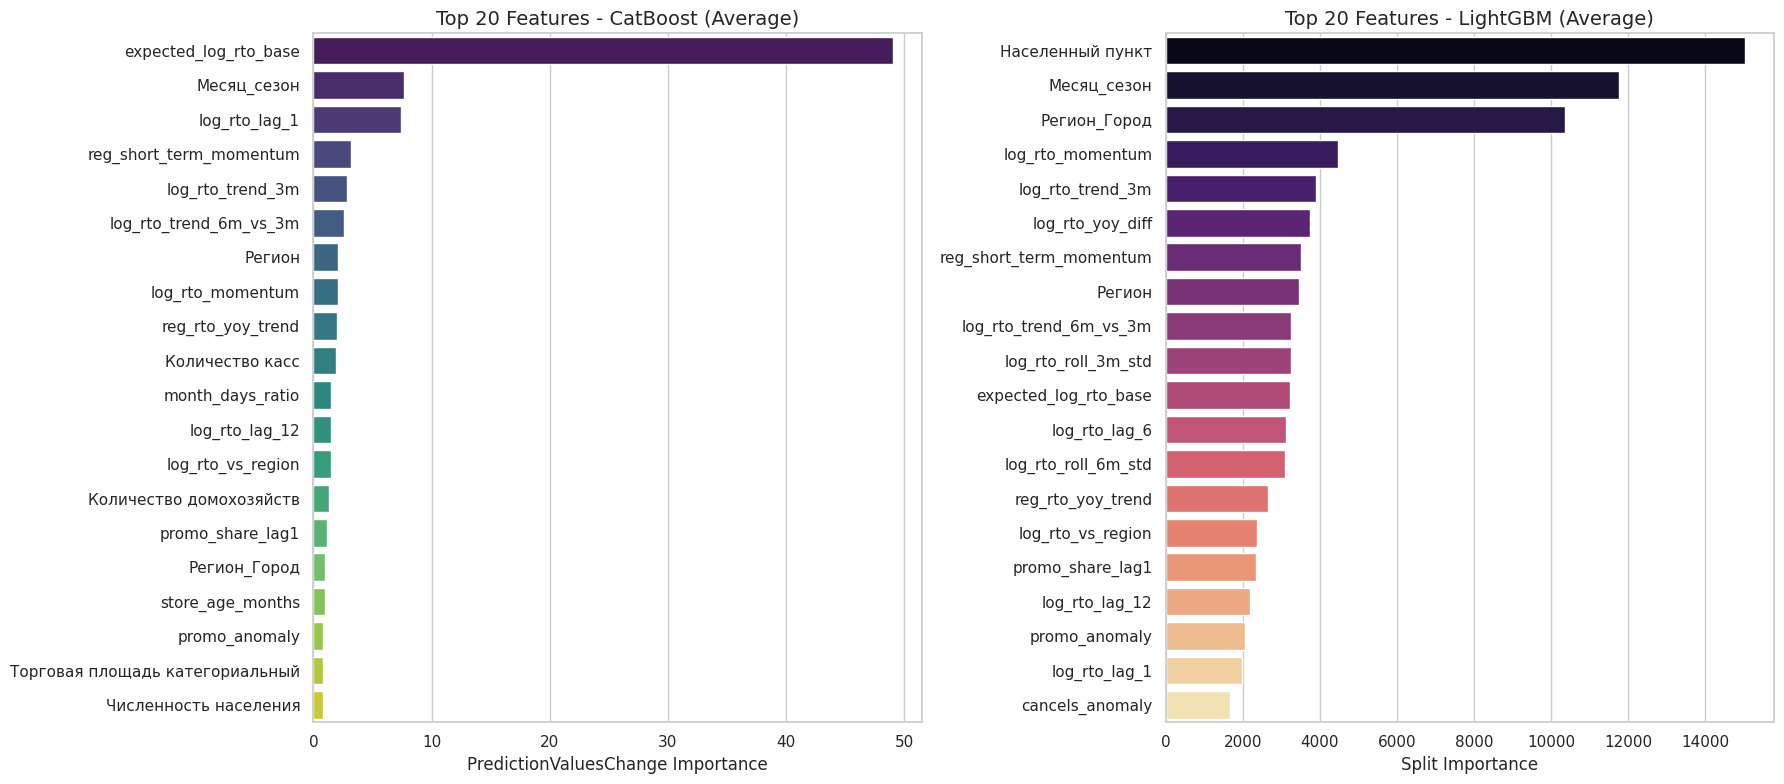

In [273]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Получаем список фичей, на которых обучались модели
feature_names = [col for col in master_df.columns if col not in DROP_COLS]

# --- 1. Усредняем важность для CatBoost ---
cb_importances = np.zeros(len(feature_names))
for model in models_cb:
    cb_importances += model.get_feature_importance()
cb_importances /= len(models_cb)

df_cb_imp = pd.DataFrame({'Feature': feature_names, 'Importance': cb_importances})
df_cb_imp = df_cb_imp.sort_values(by='Importance', ascending=False).head(20)

# --- 2. Усредняем важность для LightGBM ---
lgb_importances = np.zeros(len(feature_names))
for model in models_lgb:
    lgb_importances += model.feature_importances_
lgb_importances /= len(models_lgb)

df_lgb_imp = pd.DataFrame({'Feature': feature_names, 'Importance': lgb_importances})
df_lgb_imp = df_lgb_imp.sort_values(by='Importance', ascending=False).head(20)

# --- 3. Отрисовка графиков ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# График CatBoost
sns.barplot(data=df_cb_imp, x='Importance', y='Feature', ax=axes[0], palette='viridis')
axes[0].set_title('Top 20 Features - CatBoost (Average)', fontsize=14)
axes[0].set_xlabel('PredictionValuesChange Importance')
axes[0].set_ylabel('')

# График LightGBM
sns.barplot(data=df_lgb_imp, x='Importance', y='Feature', ax=axes[1], palette='magma')
axes[1].set_title('Top 20 Features - LightGBM (Average)', fontsize=14)
axes[1].set_xlabel('Split Importance')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## Optimize RMSE

In [65]:
cb_params = {
    'iterations': 3000, 
    'learning_rate': 0.03,
    'depth': 6,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'od_type': 'Iter',
    'od_wait': 300,
    'verbose': 500,
    'l2_leaf_reg': 5,
    'task_type': 'GPU'
}

lgbm_params = {
    'objective': 'regression_l1',
    'metric': 'mae',
    'learning_rate': 0.03,
    'n_estimators': 3000,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': 500,
    'num_leaves': 45,
    'max_depth': 7,
    'min_child_samples': 70,
    'colsample_bytree': 0.7,
    'subsample': 0.8
}

time_ids = sorted(master_df['time_id'].unique())

models_cb, models_lgb, scores_ensemble = run_cv_ensemble(
    master_df=master_df,
    val_cnt=4,
    time_ids=time_ids,
    cat_features=cat_features,
    drop_cols=DROP_COLS,
    cb_params=cb_params,
    lgbm_params=lgbm_params
)

=== Валидация на месяце: 202411 ===
0:	learn: 0.4590704	test: 0.4585690	best: 0.4585690 (0)	total: 34.7ms	remaining: 1m 43s
500:	learn: 0.0958179	test: 0.0603264	best: 0.0603264 (500)	total: 13.5s	remaining: 1m 7s
1000:	learn: 0.0920879	test: 0.0581347	best: 0.0581347 (1000)	total: 27.3s	remaining: 54.6s
1500:	learn: 0.0904169	test: 0.0575439	best: 0.0575216 (1408)	total: 41.6s	remaining: 41.5s
2000:	learn: 0.0890739	test: 0.0570302	best: 0.0570276 (1999)	total: 55.9s	remaining: 27.9s
2500:	learn: 0.0879190	test: 0.0569291	best: 0.0569240 (2485)	total: 1m 10s	remaining: 14s
2999:	learn: 0.0869745	test: 0.0568506	best: 0.0568496 (2996)	total: 1m 24s	remaining: 0us
bestTest = 0.0568495753
bestIteration = 2996
Shrink model to first 2997 iterations.
MAPE CB: 3.672 | MAPE LGBM: 3.807 | MAPE Ансамбля (CB + LGBM): 3.653%

=== Валидация на месяце: 202412 ===
0:	learn: 0.4590077	test: 0.4992391	best: 0.4992391 (0)	total: 35.8ms	remaining: 1m 47s
500:	learn: 0.0943391	test: 0.0635108	best: 0.063

# Optuna

In [ ]:
import optuna
import lightgbm as lgb
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np
import gc


df_optuna = master_df.copy()
for col in cat_features:
    df_optuna[col] = df_optuna[col].astype(str).astype('category')

def objective(trial):
    cb_params = {
        'iterations': 3500,
        'learning_rate': trial.suggest_float('cb_lr', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('cb_depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('cb_l2', 1, 15),
        'loss_function': 'MAE', #RMSE
        'eval_metric': 'MAE', #RMSE
        'random_seed': 42,
        'od_type': 'Iter',
        'od_wait': 200,
        'verbose': 0, 
        'task_type': 'GPU'
    }

    lgbm_params = {
        'objective': 'regression_l1',
        'metric': 'mae',
        'n_estimators': 3500,
        'learning_rate': trial.suggest_float('lgb_lr', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('lgb_leaves', 20, 150),
        'max_depth': -1, #trial.suggest_int('lgb_depth', 4, 10), #
        'min_child_samples': trial.suggest_int('lgb_min_child', 20, 100),
        'colsample_bytree': trial.suggest_float('lgb_colsample', 0.5, 1.0),
        'subsample': trial.suggest_float('lgb_subsample', 0.5, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,
        'device': 'cpu'
    }

    val_cnt = 4
    val_time_ids = time_ids[-val_cnt:]
    fold_scores = []

    for val_time in val_time_ids:
        train_df = df_optuna[df_optuna['time_id'] < val_time]
        val_df = df_optuna[df_optuna['time_id'] == val_time]

        X_train, y_train_raw = train_df.drop(columns=DROP_COLS), train_df['РТО']
        X_val, y_val_raw = val_df.drop(columns=DROP_COLS), val_df['РТО']

        y_train_log = np.log1p(y_train_raw)
        y_val_log = np.log1p(y_val_raw)


        train_pool = Pool(X_train, y_train_log, cat_features=cat_features)
        val_pool = Pool(X_val, y_val_log, cat_features=cat_features)
        model_cb = CatBoostRegressor(**cb_params)
        model_cb.fit(train_pool, eval_set=val_pool, verbose=False)
        preds_log_cb = model_cb.predict(X_val)


        model_lgb = lgb.LGBMRegressor(**lgbm_params)
        model_lgb.fit(X_train, y_train_log, 
                      categorical_feature=cat_features, eval_set=[(X_val, y_val_log)], 
                      callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)])
        preds_log_lgb = model_lgb.predict(X_val)


        preds_log_ensemble = (preds_log_cb + preds_log_lgb) / 2.0
        preds_raw = np.clip(np.expm1(preds_log_ensemble), 0, None)
        
        fold_mape = mean_absolute_percentage_error(y_val_raw, preds_raw) * 100
        fold_scores.append(fold_mape)


        cb_trees = model_cb.get_best_iteration()
        lgb_trees = model_lgb.best_iteration_
        print(f">> Месяц {val_time} | Остановка CB: {cb_trees} итераций | LGBM: {lgb_trees} итераций | Ансамбль MAPE: {fold_mape:.3f}%")

    del train_df, val_df, X_train, X_val
    gc.collect()


    return np.mean(fold_scores)


In [23]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nЛучший MAPE: {study.best_value * 100:.3f}%")
print("Лучшие параметры:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value},")

[I 2026-05-28 08:11:43,184] A new study created in memory with name: no-name-22027b7e-27df-4b9a-b559-c2df4af0502e


  0%|          | 0/30 [00:00<?, ?it/s]

Default metric period is 5 because MAE is/are not implemented for GPU


>> Месяц 202411 | Остановка CB: 231 итераций | LGBM: 1649 итераций | Ансамбль MAPE: 3.609%


Default metric period is 5 because MAE is/are not implemented for GPU


...

>> Месяц 202501 | Остановка CB: 680 итераций | LGBM: 3500 итераций | Ансамбль MAPE: 3.934%


Default metric period is 5 because MAE is/are not implemented for GPU


>> Месяц 202502 | Остановка CB: 257 итераций | LGBM: 3500 итераций | Ансамбль MAPE: 4.681%
[I 2026-05-28 14:11:20,985] Trial 27 finished with value: 3.990493673406537 and parameters: {'cb_lr': 0.04323645297512694, 'cb_depth': 6, 'cb_l2': 1.0970786770747807, 'lgb_lr': 0.01459213049503643, 'lgb_leaves': 97, 'lgb_min_child': 70, 'lgb_colsample': 0.7563372982044705, 'lgb_subsample': 0.8591007574625663}. Best is trial 12 with value: 3.9045268699718165.


Default metric period is 5 because MAE is/are not implemented for GPU


: 

In [ ]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nЛучший MAPE: {study.best_value * 100:.3f}%")
print("Лучшие параметры:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value},")

[I 2026-05-27 18:29:24,738] A new study created in memory with name: no-name-ab28e0e7-ea1c-4170-b418-fe75999e97a3


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-27 18:43:11,428] Trial 0 finished with value: 0.03973187307973055 and parameters: {'cb_lr': 0.018162138265968047, 'cb_depth': 5, 'cb_l2': 6.345895694896618, 'lgb_lr': 0.05123462634362668, 'lgb_leaves': 64, 'lgb_depth': 10, 'lgb_min_child': 45, 'lgb_colsample': 0.6969724742971488, 'lgb_subsample': 0.6927946076298909}. Best is trial 0 with value: 0.03973187307973055.
[I 2026-05-27 18:58:02,322] Trial 1 finished with value: 0.040164850607488416 and parameters: {'cb_lr': 0.08468698295252318, 'cb_depth': 6, 'cb_l2': 4.650477185636273, 'lgb_lr': 0.09317751927261536, 'lgb_leaves': 73, 'lgb_depth': 9, 'lgb_min_child': 86, 'lgb_colsample': 0.5707067357137063, 'lgb_subsample': 0.7883313205869169}. Best is trial 0 with value: 0.03973187307973055.
[I 2026-05-27 19:12:23,641] Trial 2 finished with value: 0.03952848280165665 and parameters: {'cb_lr': 0.0605877036398026, 'cb_depth': 6, 'cb_l2': 2.5835356506430363, 'lgb_lr': 0.04995652474084309, 'lgb_leaves': 20, 'lgb_depth': 9, 'lgb_min_ch

KeyboardInterrupt: 

# Submit

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from catboost import CatBoostRegressor, Pool

X_train_full = master_df.drop(columns=DROP_COLS).copy()
y_train_full_log = np.log1p(master_df['РТО'])

for col in cat_features:
    X_train_full[col] = X_train_full[col].astype(str).astype('category')

cb_params = {
    'iterations': 3000, 
    'learning_rate': 0.03,
    'depth': 6,
    'loss_function': 'MAE',
    'eval_metric': 'MAE',
    'random_seed': 42,
    'od_type': 'Iter',
    'od_wait': 300,
    'verbose': 500,
    'l2_leaf_reg': 5,
    'task_type': 'GPU'
}

lgbm_params = {
    'objective': 'regression_l1',
    'metric': 'mae',
    'learning_rate': 0.03,
    'n_estimators': 3000,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1, 
    'num_leaves': 45,
    'max_depth': 7,
    'min_child_samples': 70,
    'colsample_bytree': 0.7,
    'subsample': 0.8
}

print("Обучаем финальный CatBoost...")
full_train_pool = Pool(X_train_full, y_train_full_log, cat_features=cat_features)
final_cb = CatBoostRegressor(**cb_params)
final_cb.fit(full_train_pool)

print("Обучаем финальный LightGBM...")
final_lgb = lgb.LGBMRegressor(**lgbm_params)
final_lgb.fit(
    X_train_full, 
    y_train_full_log, 
    categorical_feature=cat_features
)

target_year = 2025 
target_month = 3   

print(f"Генерируем признаки для теста: {target_year}-{target_month:02d}...")
test_df = create_features_for_month(df, target_year, target_month)

for col in cat_features:
    test_df[col] = test_df[col].fillna('Missing').astype(str).astype('category')

submit_ids = test_df['new_id']

X_test = test_df.drop(columns=DROP_COLS, errors='ignore')

X_test = X_test[X_train_full.columns]

print("Считаем финальный ансамбль...")
test_preds_log_cb = final_cb.predict(X_test)
test_preds_log_lgb = final_lgb.predict(X_test)

test_preds_log = (test_preds_log_cb + test_preds_log_lgb) / 2.0

test_preds_raw = np.expm1(test_preds_log)
test_preds_raw = np.clip(test_preds_raw, 0, None)

submission = pd.DataFrame({
    'new_id': submit_ids,
    'rto': test_preds_raw
})

filename = 'submission_comb.csv'
submission.to_csv(filename, index=False)

print('done')

Обучаем финальный CatBoost...
0:	learn: 0.4602711	total: 49.2ms	remaining: 2m 27s
500:	learn: 0.0923102	total: 15.9s	remaining: 1m 19s
1000:	learn: 0.0888418	total: 31.9s	remaining: 1m 3s
1500:	learn: 0.0869389	total: 48.3s	remaining: 48.2s
2000:	learn: 0.0854994	total: 1m 4s	remaining: 32.2s
2500:	learn: 0.0844092	total: 1m 21s	remaining: 16.3s
2999:	learn: 0.0835254	total: 1m 38s	remaining: 0us
Обучаем финальный LightGBM...
done
